# Conformal Inference

https://matheusfacure.github.io/python-causality-handbook/Conformal-Inference-for-Synthetic-Control.html

https://arxiv.org/pdf/1712.09089.pdf

In [1]:
import sys
sys.path.insert(0, '../../')
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
from panel_exp.methods.tbr import TBR, TBRRidge
import numpy as np

from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife, time_jackknife_plus

In [28]:
# kansas , smoking
ds = 'meta_geo'

if ds == 'kansas':
    long_df = pd.read_csv('../data/kansas_parsed.csv')
    pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas"], 2012)
    # pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas", "Illinois"], [2012, 2012])

if ds == 'smoking':
    long_df = pd.read_csv('../data/smoking.csv')
    long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']
    pds = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California" ], [1988 ]) 

if ds == 'meta_geo':
    long_df = pd.read_csv('../data/meta_geo.csv')
    wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
    # pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105), TimePeriod(start =91, end=105)], ["chicago", "portland"])
    pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105) ], ["chicago" ])



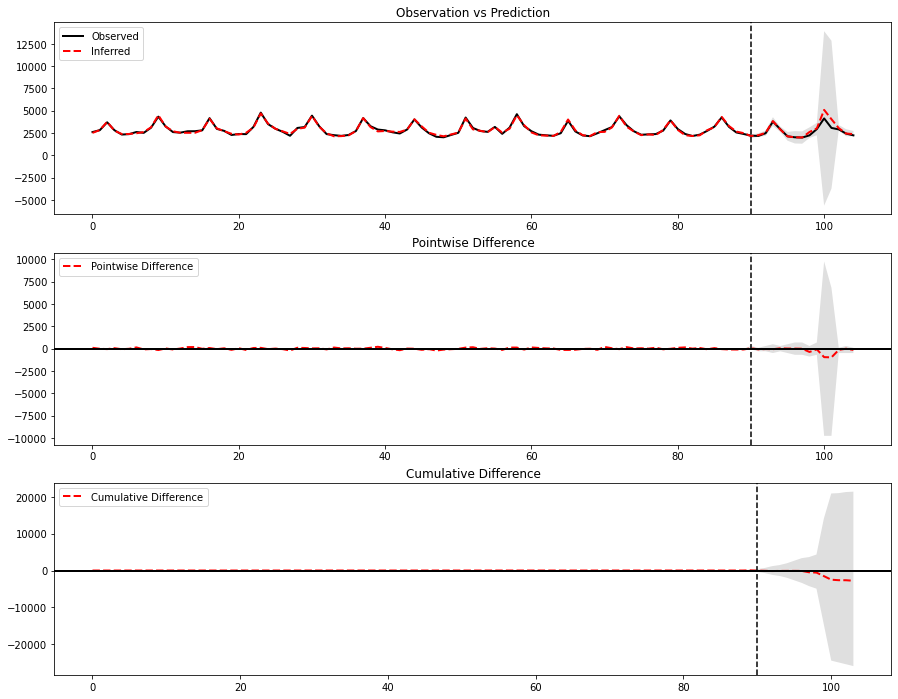

In [29]:

scm_1 = TBRRidge(inference='Conformal' )
scm_1.run_analysis(pds)
scm_1.plot()

In [25]:

scm_1.summary()

,Average,Cumulative
Actual,11.892406,202.170901
Predicted,11.950104,203.151771
,,
Absolute Effect,-0.057698,-0.98087
,,
Relative Effect,-0.482826,-0.482826


In [18]:
scm_1.results['y_upper']

array([123.        , 121.        , 123.5       , 124.40000153,
       126.69999695, 127.09999847, 128.        , 126.40000153,
       126.09999847, 121.90000153, 120.19999695, 118.59999847,
       115.40000153, 110.80000305, 104.80000305, 102.80000305,
        99.69999695,  97.5       ,  81.84903221,  85.15032361,
        75.04968096,  76.95096321,  75.75096626,  77.15161196,
        77.85225309,  75.65225614,  73.75225461,  67.55160967,
        66.05160967,  66.45225537,  60.85225309])

In [7]:

start = panel.treated_start_idxs[0]
end = panel.treated_end_idxs[0]+1

In [8]:
(scm_1.results['y'][start:end] - scm_1.results['y_hat'][start:end])

array([ -3.19121863,  -9.65884316, -10.8753068 , -13.45971389,
       -14.30083861, -17.63303398, -21.8591437 , -22.76000963,
       -23.58321138, -25.11722443, -23.20622641, -27.22818867,
       -26.68776952])

In [9]:
(scm_1.results['y'][start:end] - scm_1.results['y_hat'][start:end]).cumsum()

array([  -3.19121863,  -12.85006178,  -23.72536858,  -37.18508247,
        -51.48592108,  -69.11895506,  -90.97809876, -113.73810839,
       -137.32131976, -162.43854419, -185.6447706 , -212.87295927,
       -239.56072878])

In [11]:
(scm_1.results['y'][start:] - scm_1.results['y_upper'][start:])

array([  8.25096626,  -2.75032209,   2.75032209,  -8.25096626,
        -8.25096626, -13.75161044, -19.25225461, -19.25225461,
       -19.25225461, -13.75161044, -13.75161044, -19.25225461,
       -19.25225461])

In [7]:
(scm_1.results['y'][start:end] - scm_1.results['y_hat'][start:end]).cumsum()

array([  -3.19121863,  -12.85006178,  -23.72536858,  -37.18508247,
        -51.48592108,  -69.11895506,  -90.97809876, -113.73810839,
       -137.32131976, -162.43854419, -185.6447706 , -212.87295927,
       -239.56072878])

In [6]:
-26.68776952*13

-346.94100376

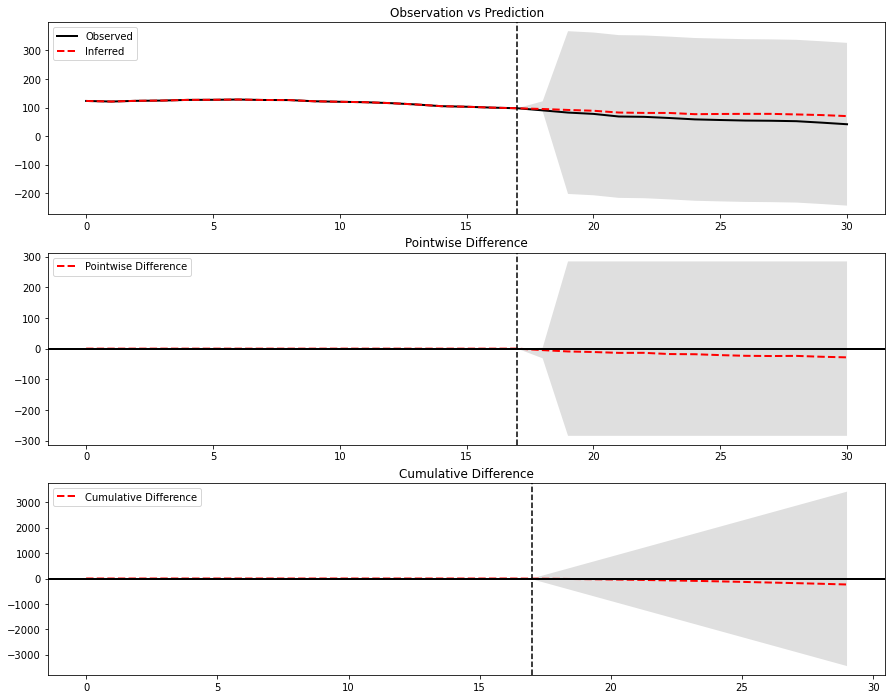

In [7]:
from panel_exp.methods.tbr import TBR, TBRRidge

est = TBRRidge(inference='Conformal' )
est.run_analysis(panel)
est.plot()

In [8]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas" ], [2012])


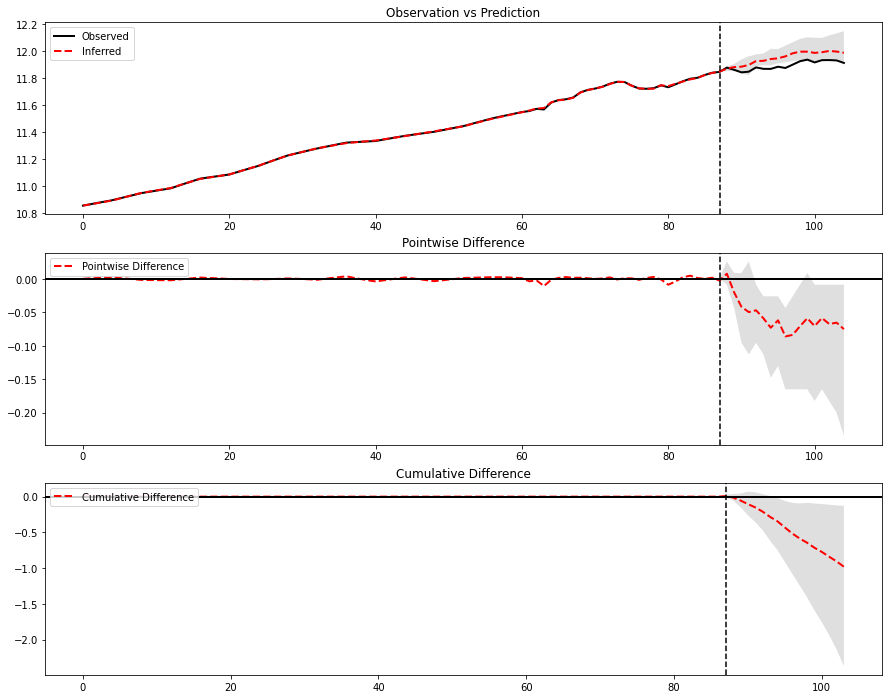

In [9]:
est = TBRRidge(inference='Conformal' )
est.run_analysis(panel_data)
est.plot()


# Issue One

I auto generate potential null hypothesis to test against (line 126 of impact ABC). The 1-alpha CI might get cut off if this is not a good estimate, so we'll need to update to pass a custom list. 

Choosing them is not easy

## AugSynth Below

In [10]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas" ], [2012])


In [11]:
asynth = AugSynth(inference='Conformal', outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])

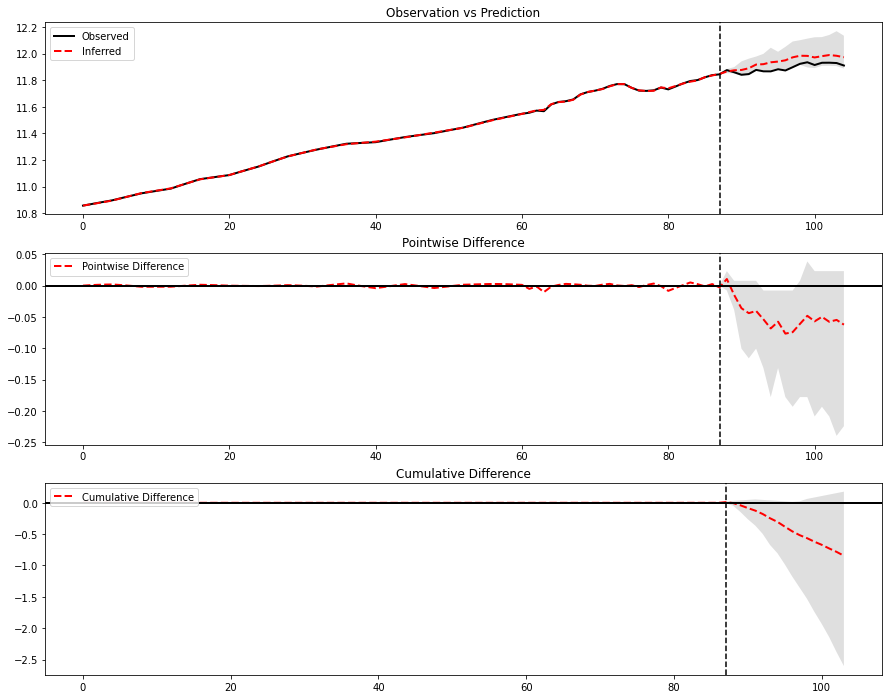

In [13]:
asynth.run_analysis(panel_data, outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])

asynth.plot()

In [14]:
from panel_exp.methods.tbr import TBR, TBRRidge


In [15]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
long_df.head()

long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']

panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas"], 2012)

print(panel_data.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


In [16]:
wide = pd.pivot_table(long_df, columns='time_unit', index='unit', values = 'value', aggfunc=sum, fill_value=0)
treated = ['Kansas']
control_units = pd.DataFrame(wide.loc[[c for c in wide.index if c not in treated]].mean(axis=0), columns=['controls']).T
treated_units = wide.loc[treated]

wide_agg = pd.concat([treated_units, control_units])
panel_data = PanelDataset(wide_agg, treated_units = treated, treated_periods=[TimePeriod(start=2012)])


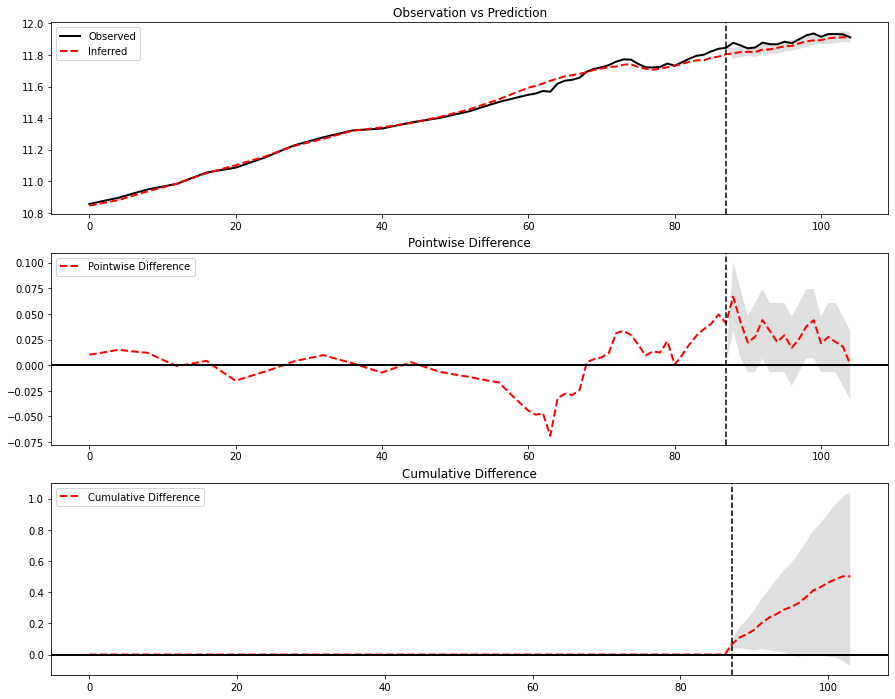

In [17]:
tbr = TBR(inference='Conformal')
tbr.run_analysis(panel_data)
tbr.plot()

In [18]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
long_df.head()

long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']

panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas"], 2012)

print(panel_data.summarize())



        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


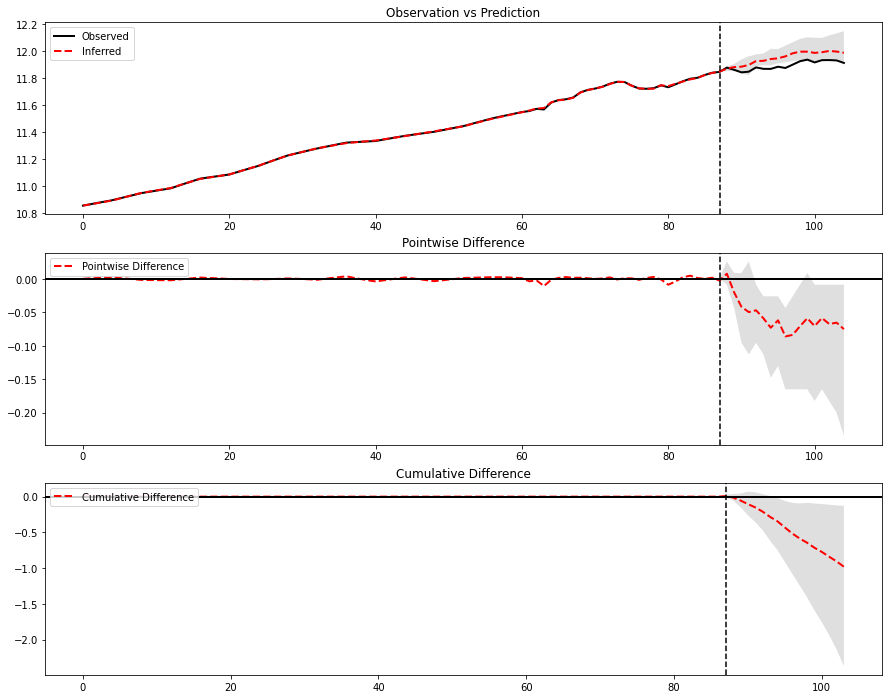

In [19]:
tbr = TBRRidge(inference='Conformal')
tbr.run_analysis(panel_data)
tbr.plot()

In [ ]:
'''
While Conformal Inference is proven to be robust in many scenarios, it is not guaranteed to work everytime. Most commonly, Conformal Inference can fail when

there is not enough days in the Pre-Treatment Period
the true impact (called in the paper as Shock Sequence Ut) is not stationary or not weakly dependent
the data is not stationary and not weakly dependent 
when our model is misspecified or inconsistent

'''